# DeepLOB "Super Model" (DeepLOB Encoder + Seq2Seq Decoder)

This notebook implements the architecture inspired by the MHF paper.

**Architecture:**
1.  **Encoder:** DeepLOB (Convolutional Blocks + Inception Module + LSTM) to extract rich spatial features from the LOB.
2.  **Decoder:** Seq2Seq LSTM with Additive Attention to generate the 60-second midprice path step-by-step.


In [1]:
import numpy as np
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import random
from utils.utils import *
from data.simulate_walk_the_book import *
from utils.datastuff import TrainCfg
from utils.train import train_val
from data.simulate_walk_the_book import simulate_walk_the_book
from utils.test import generate_test_loader
import warnings


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# Fix randomness for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

warnings.filterwarnings("ignore", category=UserWarning)


device: cuda


In [2]:
# Paths and volume_to_fill
root = Path("data") if Path("data").exists() else Path.cwd()
import sys
if str(root / "src") not in sys.path:
    sys.path.append(str(root / "src"))

symbol_dir = root / "BTCUSDT"
X_path = symbol_dir / "X_train.parquet"
Y_path = symbol_dir / "y_train.parquet"
X_test_path = symbol_dir / "X_test.parquet"
vol_path = symbol_dir / "vol_to_fill.txt"

volume_to_fill = None
if vol_path.exists():
    import re
    with open(vol_path) as f:
        m = re.search(r"([\d.]+)", f.read())
    if m:
        volume_to_fill = float(m.group(1))
print("volume_to_fill:", volume_to_fill)


volume_to_fill: 4.0


In [3]:
# DeepLOB only take LOB features as input
LOB_COLS = []
for i in range(1, 6):
    LOB_COLS.append(f"ask_price_{i}")
    LOB_COLS.append(f"ask_vol_{i}")
    LOB_COLS.append(f"bid_price_{i}")
    LOB_COLS.append(f"bid_vol_{i}")

FEATURE_COLS = LOB_COLS

# Verification print
print(f"CNN Input Width: 4 (Columns: Price/Vol/Price/Vol)")
print(f"CNN Input Height: 5 (Rows: Levels 1 through 5)")
print(f"Total Features: {len(FEATURE_COLS)}")

CNN Input Width: 4 (Columns: Price/Vol/Price/Vol)
CNN Input Height: 5 (Rows: Levels 1 through 5)
Total Features: 20


In [4]:
ASK_PRICE_COLS = ['ask_price_1', 'ask_price_2', 'ask_price_3', 'ask_price_4', 'ask_price_5']
ASK_VOL_COLS = ['ask_vol_1', 'ask_vol_2', 'ask_vol_3', 'ask_vol_4', 'ask_vol_5']
BID_PRICE_COLS = ['bid_price_1', 'bid_price_2', 'bid_price_3', 'bid_price_4', 'bid_price_5']
BID_VOL_COLS = ['bid_vol_1', 'bid_vol_2', 'bid_vol_3', 'bid_vol_4', 'bid_vol_5']

# Model Training

In [9]:
# --- Execution ---
config = TrainCfg(

    # Hyperparameters
    epochs = 100,
    batch_size = 32,
    lr = 1e-3,
    weight_decay = 1e-5,
    smooth_lambda = 0.01,
    
    # Windows
    input_window = 600,   # Look-back
    target_window = 60,   # Horizon
    val_ratio = 0.2,

    # Environment
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    
    # Features & Data
    x_path = X_path,
    y_path = Y_path,
    x_test_path = X_test_path,
    feature_cols = FEATURE_COLS,
)

model, scalers, val_loader, va_id_map, processor = train_val(config)

Epoch 01 | Train: 0.169963 | Val: 0.360403
Epoch 02 | Train: 0.063306 | Val: 0.049465
Epoch 03 | Train: 0.032252 | Val: 0.013518
Epoch 04 | Train: 0.051040 | Val: 0.063519
Epoch 05 | Train: 0.041209 | Val: 0.059435
Epoch 06 | Train: 0.042671 | Val: 0.032969
Epoch 07 | Train: 0.030227 | Val: 0.029212
Epoch 08 | Train: 0.021853 | Val: 0.041347
Epoch 09 | Train: 0.017936 | Val: 0.137833
Epoch 10 | Train: 0.018011 | Val: 0.035100
Epoch 11 | Train: 0.016170 | Val: 0.018129
Epoch 12 | Train: 0.019766 | Val: 0.017332
Epoch 13 | Train: 0.015503 | Val: 0.035474
Epoch 14 | Train: 0.016091 | Val: 0.034242
Epoch 15 | Train: 0.009867 | Val: 0.033831
Epoch 16 | Train: 0.008289 | Val: 0.025087
Epoch 17 | Train: 0.020133 | Val: 0.030386
Epoch 18 | Train: 0.012849 | Val: 0.148030
Epoch 19 | Train: 0.013927 | Val: 0.022229
Epoch 20 | Train: 0.017123 | Val: 0.101251
Epoch 21 | Train: 0.013193 | Val: 0.055551
Epoch 22 | Train: 0.006665 | Val: 0.037464
Epoch 23 | Train: 0.007388 | Val: 0.027748
Epoch 24 | 

# Model-Based Predictions

## Cell

In [65]:
# Implementation error for the model

import pandas as pd
import numpy as np
from data.simulate_walk_the_book import simulate_walk_the_book

# --- 1. Generate predictions using val_loader ---
model.eval()
all_preds = []

with torch.no_grad():
    for xb, yb, target in val_loader:
        xb = xb.to(config.device)
        pred = model(xb, y_teacher=None)
        all_preds.append(pred.cpu().numpy())

val_preds = np.concatenate(all_preds, axis=0)  # Shape: [num_val_ids, 60]

# Get validation IDs
val_ids = [int(uid) for idx, uid in va_id_map.cpu().numpy()]
print(f"Validation predictions shape: {val_preds.shape}")
print(f"Number of validation instruments: {len(val_ids)}")

# --- 2. Reload raw Y validation data to simulate walking the book ---
Y_raw = pd.read_parquet(Y_path).sort_values(["anonymized_id", "time_in_hour"])
Y_val_raw = Y_raw[Y_raw["anonymized_id"].isin(val_ids)].copy()

# --- 3. Column definitions ---
ASK_PRICE_COLS = ['ask_price_1', 'ask_price_2', 'ask_price_3', 'ask_price_4', 'ask_price_5']
ASK_VOL_COLS = ['ask_vol_1', 'ask_vol_2', 'ask_vol_3', 'ask_vol_4', 'ask_vol_5']
BID_PRICE_COLS = ['bid_price_1', 'bid_price_2', 'bid_price_3', 'bid_price_4', 'bid_price_5']
BID_VOL_COLS = ['bid_vol_1', 'bid_vol_2', 'bid_vol_3', 'bid_vol_4', 'bid_vol_5']

# --- 4. Calculate MODEL implementation error ---
model_bps = []

for i, anon_id in enumerate(val_ids):
    df_inst = Y_val_raw[Y_val_raw["anonymized_id"] == anon_id].sort_values("time_in_hour")
    
    if len(df_inst) != 60:
        continue
    
    ask_prices = df_inst[ASK_PRICE_COLS].to_numpy()
    ask_vols = df_inst[ASK_VOL_COLS].to_numpy()
    bid_prices = df_inst[BID_PRICE_COLS].to_numpy()
    bid_vols = df_inst[BID_VOL_COLS].to_numpy()
    close_price = df_inst['close'].dropna().iloc[-1]
    
    # Model-based positions
    mid_preds = val_preds[i]
    pred_close = mid_preds[-1]
    
    price_distance = abs(pred_close - mid_preds)
    # price_advantage = np.maximum(price_advantage, 0)

    weights = 1 - (price_distance / price_distance.sum())
    
    # if price_advantage.sum() > 0:
    #     weights = price_advantage / price_advantage.sum()
    # else:
    #     weights = np.zeros(60)
    #     weights[-14:] = 1.0 / 14  # Fallback to TWAP
    
    model_positions = weights * volume_to_fill
    
    # Simulate
    model_vol, model_avg_price = simulate_walk_the_book(
        model_positions, ask_prices, ask_vols, bid_prices, bid_vols
    )
    
    if model_vol > 0 and not np.isnan(model_avg_price):
        impl_error = np.abs(model_avg_price - close_price) / close_price * 10000
        vol_penalty = min(100.0, volume_to_fill / model_vol)
        model_bps.append(impl_error * vol_penalty)

model_bps = np.array(model_bps)

print(f"\n{'='*50}")
print(f"MODEL IMPLEMENTATION ERROR")
print(f"{'='*50}")
print(f"Instruments evaluated: {len(model_bps)}")
print(f"Mean:   {model_bps.mean():.4f} bps")
print(f"Median: {np.median(model_bps):.4f} bps")
print(f"Std:    {model_bps.std():.4f} bps")
print(f"Min:    {model_bps.min():.4f} bps")
print(f"Max:    {model_bps.max():.4f} bps")
print(f"{'='*50}")

Validation predictions shape: (141, 60)
Number of validation instruments: 141

MODEL IMPLEMENTATION ERROR
Instruments evaluated: 141
Mean:   0.1671 bps
Median: 0.1421 bps
Std:    0.1355 bps
Min:    0.0049 bps
Max:    0.7255 bps


## Function - Generate Test Predictions

In [ ]:
# --- 1. Generate predictions using val_loader ---
model.eval()
test_preds = []

test_loader, scalers, test_map, processor = generate_test_loader(config)

with torch.no_grad():
    for xb in test_loader:
        xb = xb.to(config.device)
        pred = model(xb, y_teacher=None)
        test_preds.append(pred.cpu().numpy())

test_preds = np.concatenate(test_preds, axis=0)  # Shape: [num_val_ids, 60]

# Get validation IDs
test_ids = [int(uid) for idx, uid in test_map.cpu().numpy()]
print(f"Validation predictions shape: {test_preds.shape}")
print(f"Number of testing instruments: {len(test_ids)}")

test_positions = pd.DataFrame()

for i, anon_id in enumerate(test_ids):
    
    # Model-based positions
    mid_preds = test_preds[i]
    pred_close = mid_preds[-1]
    
    price_distance = abs(pred_close - mid_preds)
    # price_advantage = np.maximum(price_advantage, 0)

    weights = 1 - (price_distance / price_distance.sum())
    
    # if price_advantage.sum() > 0:
    #     weights = price_advantage / price_advantage.sum()
    # else:
    #     weights = np.zeros(60)
    #     weights[-14:] = 1.0 / 14  # Fallback to TWAP
    
    model_positions = weights * volume_to_fill

    df = pd.DataFrame({
        'anonymized_id': anon_id,
        'time_in_hour': np.arange(60), # TODO
        'position': model_positions
    })

    test_positions = pd.concat([test_positions, df], ignore_index=True)

test_positions

Validation predictions shape: (303, 60)
Number of testing instruments: 303


,anonymized_id,time_in_hour,position
0,5.692284e+16,0,0.000000
1,5.692284e+16,1,0.000000
2,5.692284e+16,2,0.000000
3,5.692284e+16,3,0.000000
4,5.692284e+16,4,0.000000
...,...,...,...
18175,1.841373e+19,55,0.285714
18176,1.841373e+19,56,0.285714
18177,1.841373e+19,57,0.285714
18178,1.841373e+19,58,0.285714


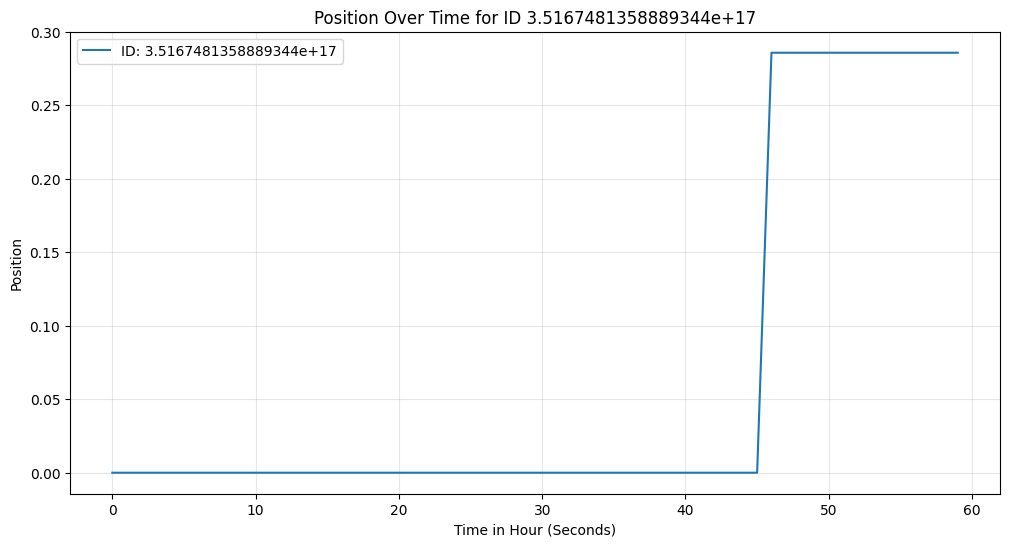

In [64]:
import matplotlib.pyplot as plt

# 1. Extract the scalar value
# Using .iloc[0] ensures you get the value, not a Series
target_id = test_positions["anonymized_id"].iloc[300]

# 2. Filter using Pandas boolean indexing
# We use the standard bracket notation here
specific_df = test_positions[test_positions["anonymized_id"] == target_id].copy()

# 3. Sort by time
specific_df = specific_df.sort_values("time_in_hour")

# 4. Plot
plt.figure(figsize=(12, 6))
plt.plot(specific_df["time_in_hour"], specific_df["position"], label=f"ID: {target_id}")

plt.title(f"Position Over Time for ID {target_id}")
plt.xlabel("Time in Hour (Seconds)")
plt.ylabel("Position")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# TWAP

In [11]:
# Implementation error for the baseline (TWAP)

K_SECONDS = 14  # TWAP window: last K seconds

baseline_bps = []

for i, anon_id in enumerate(val_ids):
    df_inst = Y_val_raw[Y_val_raw["anonymized_id"] == anon_id].sort_values("time_in_hour")
    
    if len(df_inst) != 60:
        continue
    
    ask_prices = df_inst[ASK_PRICE_COLS].to_numpy()
    ask_vols = df_inst[ASK_VOL_COLS].to_numpy()
    bid_prices = df_inst[BID_PRICE_COLS].to_numpy()
    bid_vols = df_inst[BID_VOL_COLS].to_numpy()
    close_price = df_inst['close'].dropna().iloc[-1]
    
    # Baseline TWAP positions
    baseline_positions = np.zeros(60)
    baseline_positions[-K_SECONDS:] = volume_to_fill / K_SECONDS
    
    # Simulate
    baseline_vol, baseline_avg_price = simulate_walk_the_book(
        baseline_positions, ask_prices, ask_vols, bid_prices, bid_vols
    )
    
    if baseline_vol > 0 and not np.isnan(baseline_avg_price):
        impl_error = np.abs(baseline_avg_price - close_price) / close_price * 10000
        vol_penalty = min(100.0, volume_to_fill / baseline_vol)
        baseline_bps.append(impl_error * vol_penalty)

baseline_bps = np.array(baseline_bps)

print(f"\n{'='*50}")
print(f"BASELINE (TWAP-{K_SECONDS}s) IMPLEMENTATION ERROR")
print(f"{'='*50}")
print(f"Instruments evaluated: {len(baseline_bps)}")
print(f"Mean:   {baseline_bps.mean():.4f} bps")
print(f"Median: {np.median(baseline_bps):.4f} bps")
print(f"Std:    {baseline_bps.std():.4f} bps")
print(f"Min:    {baseline_bps.min():.4f} bps")
print(f"Max:    {baseline_bps.max():.4f} bps")
print(f"{'='*50}")


BASELINE (TWAP-14s) IMPLEMENTATION ERROR
Instruments evaluated: 141
Mean:   1.3232 bps
Median: 1.1836 bps
Std:    1.0940 bps
Min:    0.0000 bps
Max:    9.0855 bps


# Predictive_Scheduler Predictions

## Cell

In [12]:
# Implementation error for the predictive scheduler

from predictive_scheduler import build_schedule_from_forecasts, ScheduleConfig

# Configure the scheduler
sched_cfg = ScheduleConfig(
    window=14,       # Only trade in last 14 seconds
    alpha=0.1,       # 10% model, 90% TWAP blend
    price_cap=3.0,   # Cap extreme scores
)

scheduler_bps = []

for i, anon_id in enumerate(val_ids):
    df_inst = Y_val_raw[Y_val_raw["anonymized_id"] == anon_id].sort_values("time_in_hour")
    
    if len(df_inst) != 60:
        continue
    
    ask_prices = df_inst[ASK_PRICE_COLS].to_numpy()
    ask_vols = df_inst[ASK_VOL_COLS].to_numpy()
    bid_prices = df_inst[BID_PRICE_COLS].to_numpy()
    bid_vols = df_inst[BID_VOL_COLS].to_numpy()
    close_price = df_inst['close'].dropna().iloc[-1]
    
    # Use predictive_scheduler to build positions
    mid_preds = val_preds[i]
    scheduler_positions = build_schedule_from_forecasts(
        mid_pred=mid_preds,
        volume_to_fill=volume_to_fill,
        spread_pred=None,  # We don't predict spread
        liq_pred=None,     # We don't predict liquidity
        cfg=sched_cfg
    )
    
    # Simulate
    sched_vol, sched_avg_price = simulate_walk_the_book(
        scheduler_positions, ask_prices, ask_vols, bid_prices, bid_vols
    )
    
    if sched_vol > 0 and not np.isnan(sched_avg_price):
        impl_error = np.abs(sched_avg_price - close_price) / close_price * 10000
        vol_penalty = min(100.0, volume_to_fill / sched_vol)
        scheduler_bps.append(impl_error * vol_penalty)

scheduler_bps = np.array(scheduler_bps)

print(f"\n{'='*50}")
print(f"PREDICTIVE SCHEDULER IMPLEMENTATION ERROR")
print(f"{'='*50}")
print(f"Config: window={sched_cfg.window}, alpha={sched_cfg.alpha}")
print(f"Instruments evaluated: {len(scheduler_bps)}")
print(f"Mean:   {scheduler_bps.mean():.4f} bps")
print(f"Median: {np.median(scheduler_bps):.4f} bps")
print(f"Std:    {scheduler_bps.std():.4f} bps")
print(f"Min:    {scheduler_bps.min():.4f} bps")
print(f"Max:    {scheduler_bps.max():.4f} bps")
print(f"{'='*50}")


PREDICTIVE SCHEDULER IMPLEMENTATION ERROR
Config: window=14, alpha=0.1
Instruments evaluated: 141
Mean:   1.3145 bps
Median: 1.2139 bps
Std:    1.1117 bps
Min:    0.0006 bps
Max:    10.0006 bps


## Function

# Test Predictions

In [25]:
from utils.test import generate_test_predictions

# --- Execution ---
test_preds, test_id_map = generate_test_predictions(model, config, processor, num_ids=5)

Loading test data...
Sampling first 5 IDs for inference...
Preprocessing test data...
Running inference on 5 instruments...


* **The Map:** This `test_id_np` array pairs the model's row index with the actual anonymized ID.

In [26]:
# Convert test_id_map to numpy (handles both CPU and GPU tensors)
if hasattr(test_id_map, 'cpu'):
    test_id_np = test_id_map.cpu().numpy().astype(np.uint64)
else:
    test_id_np = np.array(test_id_map, dtype=np.uint64)

# Create a quick summary for inspection
print(f"{'Anonymized ID':<25} | {'First Pred (t+1)':<18} | {'Last Pred (t+60)':<18}")
print("-" * 70)

for i in range(len(test_id_np)):  # Look at first 5
    orig_id = test_id_np[i, 1]
    first_p = test_preds[i, 0]
    last_p  = test_preds[i, -1]
    print(f"{str(orig_id):<25} | {first_p:18.6f} | {last_p:18.6f}")

Anonymized ID             | First Pred (t+1)   | Last Pred (t+60)  
----------------------------------------------------------------------
1023152567978923567       |           0.182149 |           0.080546
1979785869963446770       |           0.318317 |           0.184817
8976814953002534170       |          -1.368540 |          -1.459478
11173006297798552083      |          -0.172581 |          -0.212997
11844484052188582231      |           0.646483 |           0.473361


In [27]:
# 1. Load your data into Polars
# Using test_id_np[:, 1] for our big IDs
id_df = pl.DataFrame({
    "anonymized_id": test_id_np[:, 1],
    "preds": test_preds.tolist()  # This creates a column of lists, each 60 items long
})

# 2. Explode and add the time duration
final_df = (
    id_df.explode("preds")  # This turns each list of 60 into 60 separate rows
    .with_columns(
        # This counts 0 to 59 for every ID
        pl.col("anonymized_id").cum_count().over("anonymized_id").sub(1).alias("step")
    )
    .with_columns(
        # Create the duration starting at 59 minutes
        pl.duration(minutes=59, seconds=pl.col("step")).alias("time_in_hour")
    )
    .select([
        "anonymized_id",
        "time_in_hour",
        pl.col("preds").alias("mid_price_pred")
    ])
)

display(final_df.head(65))

anonymized_id,time_in_hour,mid_price_pred
u64,duration[μs],f64
1023152567978923567,59m,0.182149
1023152567978923567,59m 1s,0.178947
1023152567978923567,59m 2s,0.176857
1023152567978923567,59m 3s,0.174819
1023152567978923567,59m 4s,0.17265
…,…,…
1979785869963446770,59m,0.318317
1979785869963446770,59m 1s,0.316183
1979785869963446770,59m 2s,0.314694


# Final Comparison of Position Prediction

In [28]:
test_preds.shape

(5, 60)

In [29]:
bla = pd.read_parquet(X_test_path).sort_values(["anonymized_id", "time_in_hour"])
bla["anonymized_id"].unique().shape

(303,)

In [30]:
final_df.shape[0] / 60

5.0

In [31]:
final_df["position"].isclose(test_preds[""])

ColumnNotFoundError: "position" not found